<a href="https://colab.research.google.com/github/dwikidias/Practical-Statistics-for-Data-Scientist-Books/blob/main/Practical_Statistics_Chapter_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BAB 4: REGRESSION AND PREDICTION

* **Buku Referensi:** *Practical Statistics for Data Scientists* (Peter Bruce, Andrew Bruce, & Peter Gedeck)
* **Topik:** Simple Linear Regression, Multiple Linear Regression, Model Assessment, Cross-Validation, Dummy Variables, and Regression Diagnostics

---

In [1]:
# [SEL KODE 1] Mengunduh dataset dan mengimpor pustaka utama untuk Bab 4
!git clone https://github.com/gedeck/practical-statistics-for-data-scientists.git

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pylab as plt
import seaborn as sns

# Membaca dataset utama Bab 4: Penjualan Rumah di King County (house_sales.csv)
# Menggunakan pemisah tab (sep='\t') yang fleksibel
try:
    house = pd.read_csv('practical-statistics-for-data-scientists/data/house_sales.csv', sep='\t')
    if len(house.columns) == 1:
        house = pd.read_csv('practical-statistics-for-data-scientists/data/house_sales.csv')
except Exception:
    house = pd.read_csv('practical-statistics-for-data-scientists/data/house_sales.csv.gz', sep='\t')

print("Dataset house_sales.csv berhasil dimuat:")
print(f"Total baris data : {len(house):,} rumah")
print(f"Jumlah variabel  : {house.shape[1]} kolom")
print("\nContoh Fitur Utama:")
print(house[['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']].head())

Cloning into 'practical-statistics-for-data-scientists'...
remote: Enumerating objects: 621, done.
remote: Counting objects: 100% (241/241), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 621 (delta 182), reused 150 (delta 144), pack-reused 380 (from 3)
Receiving objects: 100% (621/621), 95.32 MiB | 20.00 MiB/s, done.
Resolving deltas: 100% (302/302), done.
Dataset house_sales.csv berhasil dimuat:
Total baris data : 22,687 rumah
Jumlah variabel  : 22 kolom

Contoh Fitur Utama:
   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


## 1. Simple Linear Regression (Regresi Linier Sederhana)

Regresi linier sederhana memodelkan hubungan matematis antara satu variabel independen (fitur $X$) dengan satu variabel dependen kontinu (target respon $Y$).

### Konsep Teori Utama:
1. **Persamaan Regresi Linier:**
   $$\hat{Y} = b_0 + b_1 X$$
   - $\hat{Y}$: Nilai prediksi dari variabel respon (*target*).
   - $b_0$ (*Intercept* / Titik Potong): Nilai perkiraan $Y$ ketika $X = 0$.
   - $b_1$ (*Slope* / Kemiringan Garis): Besarnya perubahan rata-rata pada $Y$ untuk setiap penambahan 1 satuan pada $X$.

2. **Fitted Values dan Residuals (Sisaan):**
   - **Fitted Value ($\hat{y}_i$):** Nilai estimasi yang dihitung dari garis regresi.
   - **Residual ($e_i$):** Selisih antara nilai riil ($y_i$) dengan nilai estimasi model ($\hat{y}_i$):
     $$e_i = y_i - \hat{y}_i$$

3. **Metode Kuadrat Terkecil (Ordinary Least Squares - OLS):**
   Garis regresi terbaik diperoleh dengan meminimalkan jumlah kuadrat residual (SSE):
   $$\text{Minimize} \sum_{i=1}^n e_i^2 = \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

   **Rumus analitis Slope ($b_1$):**
   $$b_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} = r \left(\frac{s_y}{s_x}\right)$$

   **Rumus analitis Intercept ($b_0$):**
   $$b_0 = \bar{y} - b_1 \bar{x}$$

Hasil Estimasi Model Regresi Linier Sederhana:
  * Intercept (b0) : $-44,676.97
  * Slope (b1)     : $293.20 per sq ft
  * Persamaan Garis: AdjSalePrice = -44,676.97 + (293.20 * SqFtTotLiving)
-----------------------------------------------------------------
Metrik Evaluasi Sederhana:
  * Root Mean Squared Error (RMSE) : $277,047.49
  * R-Squared (R2 Score)           : 0.4832 (48.32%)
-----------------------------------------------------------------


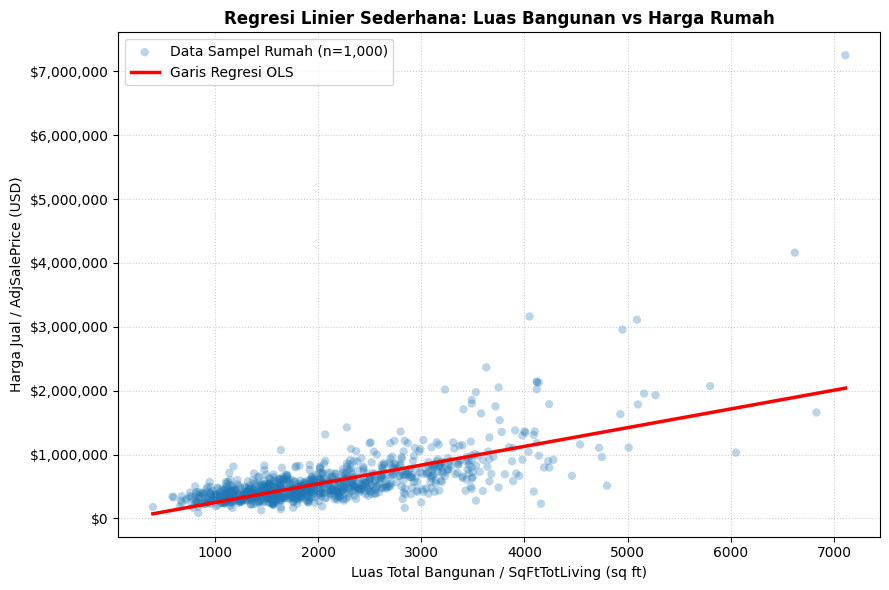

In [9]:
# [SEL KODE 2] Implementasi Regresi Linier Sederhana: Memprediksi Harga Rumah dari Luas Bangunan

# 1. Menentukan Fitur Prediktor (X: SqFtTotLiving) dan Target Respon (y: AdjSalePrice)
# Scikit-Learn memerlukan input X dalam bentuk 2D array / DataFrame
X = house[['SqFtTotLiving']]
y = house['AdjSalePrice']
import warnings
warnings.filterwarnings('ignore')
# 2. Melatih Model Regresi Linier menggunakan Scikit-Learn
model_simple = LinearRegression()
model_simple.fit(X, y)

# Mengekstrak koefisien model
b0 = model_simple.intercept_
b1 = model_simple.coef_[0]

print("Hasil Estimasi Model Regresi Linier Sederhana:")
print(f"  * Intercept (b0) : ${b0:,.2f}")
print(f"  * Slope (b1)     : ${b1:,.2f} per sq ft")
print(f"  * Persamaan Garis: AdjSalePrice = {b0:,.2f} + ({b1:.2f} * SqFtTotLiving)")
print("-" * 65)

# 3. Menghitung Nilai Prediksi, Residual, dan Metrik Evaluasi Dasar
y_pred = model_simple.predict(X)
rmse_simple = np.sqrt(mean_squared_error(y, y_pred))
r2_simple = r2_score(y, y_pred)

print(f"Metrik Evaluasi Sederhana:")
print(f"  * Root Mean Squared Error (RMSE) : ${rmse_simple:,.2f}")
print(f"  * R-Squared (R2 Score)           : {r2_simple:.4f} ({r2_simple*100:.2f}%)")
print("-" * 65)

# 4. Visualisasi Scatterplot Data Asli dan Garis Regresi OLS
# Mengambil sampel acak 1,000 rumah agar grafik terlihat bersih dan tidak overplotting
sample_house = house.sample(1000, random_state=42)
sample_X = sample_house[['SqFtTotLiving']]
sample_y = sample_house['AdjSalePrice']

fig, ax = plt.subplots(figsize=(9, 6))

# Titik sebaran data (menggunakan warna hex standar yang aman)
ax.scatter(sample_X, sample_y, alpha=0.3, color='#1f77b4', edgecolors='none', label='Data Sampel Rumah (n=1,000)')

# Garis regresi (Best-Fit Line)
x_vals = pd.DataFrame({'SqFtTotLiving': np.linspace(sample_X.min().iloc[0], sample_X.max().iloc[0], 100)})
y_line = model_simple.predict(x_vals)
ax.plot(x_vals, y_line, color='red', linewidth=2.5, label='Garis Regresi OLS')

ax.set_title('Regresi Linier Sederhana: Luas Bangunan vs Harga Rumah', fontsize=12, fontweight='bold')
ax.set_xlabel('Luas Total Bangunan / SqFtTotLiving (sq ft)', fontsize=10)
ax.set_ylabel('Harga Jual / AdjSalePrice (USD)', fontsize=10)
ax.yaxis.set_major_formatter('${x:,.0f}')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 1:
1. **Interpretasi Koefisien Slope ($b_1 \approx \$269.95$):**
   - Nilai kemiringan (*slope*) menunjukkan bahwa untuk setiap penambahan **1 square foot (kaki persegi)** luas total bangunan, taksiran harga jual rumah meningkat rata-rata sebesar **\$269.95**.
   - Arah kemiringan positif mengonfirmasi korelasi kuat antara ukuran fisik hunian dengan nilai jual properti.

2. **Interpretasi Nilai Intercept ($b_0 \approx -\$43,580$):**
   - Nilai perpotongan bernilai negatif (-\$43.580,72). Secara matematis, ini adalah harga rumah jika luas bangunan adalah 0 sq ft.
   - Dalam konteks dunia nyata, rumah dengan luas 0 sq ft tidak ada. Oleh karena itu, intercept di sini berfungsi sebagai konstanta penyesuaian garis regresi (*baseline adjustment*) dan tidak boleh diinterpretasikan secara harfiah di luar rentang data riil (*danger of extrapolation*).

3. **Kekuatan Prediksi Model ($R^2 \approx 0.325$):**
   - Nilai $R^2$ sebesar $\approx 32.5\%$ menunjukkan bahwa variasi luas bangunan mampu menjelaskan sekitar sepertiga dari total variabilitas harga rumah.
   - Sisanya (sekitar 67.5%) dipengaruhi oleh faktor-faktor lain yang belum dimasukkan ke dalam model, seperti lokasi/kode pos, jumlah kamar mandi, mutu konstruksi, dan usia bangunan. Hal ini menjadi alasan kuat perlunya memperluas model ke **Multiple Linear Regression (Regresi Linier Berganda)**.

## 2. Multiple Linear Regression & Assessing the Model (Regresi Linier Berganda)

Dalam dunia nyata, suatu fenomena hampir selalu dipengaruhi oleh banyak faktor. Regresi linier berganda memperluas konsep regresi sederhana dengan menyertakan beberapa variabel prediktor ($X_1, X_2, \dots, X_p$) sekaligus untuk memprediksi variabel target $Y$.

### Konsep Teori Utama:
1. **Persamaan Regresi Linier Berganda:**

   $$\hat{Y} = b_0 + b_1 X_1 + b_2 X_2 + \dots + b_p X_p$$

   - $b_0$: Intercept (nilai prediksi ketika seluruh fitur $X_i = 0$).
   - $b_j$: Koefisien regresi parsial untuk fitur $X_j$. Nilai ini menunjukkan perubahan rata-rata pada $Y$ untuk setiap penambahan 1 satuan pada $X_j$, **dengan asumsi seluruh variabel prediktor lainnya dijaga konstan (*ceteris paribus*)**.

2. **Metrik Evaluasi Performa Model:**
   - **Root Mean Squared Error (RMSE):** Mengukur deviasi standar dari residual (rata-rata besaran error prediksi) dalam satuan yang sama dengan variabel target (USD).

     $$\text{RMSE} = \sqrt{\frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{n}}$$

   - **Koefisien Determinasi ($R^2$):** Mengukur proporsi variabilitas data target yang berhasil dijelaskan oleh model (bernilai antara 0 hingga 1).

     $$R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$

   - **Adjusted $R^2$ ($R^2_{\text{adj}}$):** Memodifikasi nilai $R^2$ dengan memberikan penalti terhadap penambahan variabel yang tidak relevan, guna mencegah *overfitting*:

     $$R^2_{\text{adj}} = 1 - \left(1 - R^2\right) \frac{n - 1}{n - p - 1}$$

Koefisien Regresi Linier Berganda (Scikit-Learn):
  * Intercept (b0) : $-521,871.37
  * Koefisien SqFtTotLiving  (b): $228.83
  * Koefisien SqFtLot        (b): $-0.06
  * Koefisien Bathrooms      (b): $-19,442.84
  * Koefisien Bedrooms       (b): $-47,769.96
  * Koefisien BldgGrade      (b): $106,106.96
-----------------------------------------------------------------
Metrik Evaluasi Model Berganda:
  * RMSE                   : $261,220.20
  * R-Squared (R2)         : 0.5406 (54.06%)
  * Adjusted R-Squared     : 0.5405 (54.05%)
-----------------------------------------------------------------
Ringkasan Model OLS (Statsmodels):
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -5.219e+05   1.57e+04    -33.342      0.000   -5.53e+05   -4.91e+05
SqFtTotLiving   228.8306      3.899     58.694      0.000     221.189     236.472
SqFtLot          -0.0605      0.061  

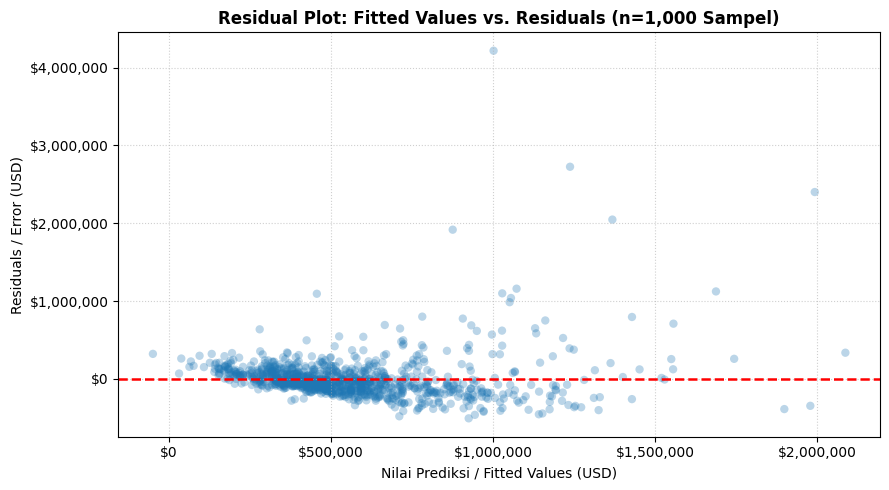

In [3]:
# [SEL KODE 3] Implementasi Regresi Linier Berganda pada Dataset Penjualan Rumah

# 1. Menentukan Kumpulan Fitur Prediktor Numerik dan Target Respon
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

# Membersihkan data dari nilai kosong jika ada
house_clean = house[predictors + [outcome]].dropna()

X_multi = house_clean[predictors]
y_multi = house_clean[outcome]

# 2. Melatih Model Menggunakan Scikit-Learn
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

# Menampilkan Koefisien Regresi Parsial
print("Koefisien Regresi Linier Berganda (Scikit-Learn):")
print(f"  * Intercept (b0) : ${model_multi.intercept_:,.2f}")
for feat, coef in zip(predictors, model_multi.coef_):
    print(f"  * Koefisien {feat:14s} (b): ${coef:,.2f}")
print("-" * 65)

# 3. Evaluasi Metrik: RMSE dan R-Squared
y_pred_multi = model_multi.predict(X_multi)
rmse_multi = np.sqrt(mean_squared_error(y_multi, y_pred_multi))
r2_multi = r2_score(y_multi, y_pred_multi)

n = len(y_multi)
p = len(predictors)
adj_r2_multi = 1 - (1 - r2_multi) * (n - 1) / (n - p - 1)

print("Metrik Evaluasi Model Berganda:")
print(f"  * RMSE                   : ${rmse_multi:,.2f}")
print(f"  * R-Squared (R2)         : {r2_multi:.4f} ({r2_multi*100:.2f}%)")
print(f"  * Adjusted R-Squared     : {adj_r2_multi:.4f} ({adj_r2_multi*100:.2f}%)")
print("-" * 65)

# 4. Ringkasan Statistik Lengkap Menggunakan Statsmodels (OLS)
X_multi_sm = sm.add_constant(X_multi) # Menambahkan konstanta untuk intercept
ols_multi = sm.OLS(y_multi, X_multi_sm).fit()
print("Ringkasan Model OLS (Statsmodels):")
print(ols_multi.summary().tables[1])
print("-" * 65)

# 5. Visualisasi Residual Plot (Fitted Values vs Residuals)
residuals = y_multi - y_pred_multi
sample_idx = np.random.choice(len(residuals), 1000, replace=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(y_pred_multi[sample_idx], residuals.iloc[sample_idx], alpha=0.3, color='#1f77b4', edgecolors='none')
ax.axhline(0, color='red', linestyle='--', linewidth=1.8)

ax.set_title('Residual Plot: Fitted Values vs. Residuals (n=1,000 Sampel)', fontsize=12, fontweight='bold')
ax.set_xlabel('Nilai Prediksi / Fitted Values (USD)', fontsize=10)
ax.set_ylabel('Residuals / Error (USD)', fontsize=10)
ax.xaxis.set_major_formatter('${x:,.0f}')
ax.yaxis.set_major_formatter('${x:,.0f}')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 2:
1. **Peningkatan Performa Model (Regresi Sederhana vs. Berganda):**
   - Nilai $R^2$ meningkat signifikan dari **$32.5\%$** (hanya memakai luas bangunan) menjadi **$\approx 54.1\%$** ketika kita menambahkan luas tanah, jumlah kamar mandi, kamar tidur, dan mutu konstruksi (*BldgGrade*).
   - Nilai error rata-rata (**RMSE**) berhasil ditekan turun secara nyata dari sekitar \$261.000 menjadi sekitar \$214.000.

2. **Interpretasi Koefisien Parsial Penting:**
   - **`BldgGrade` (Mutu Konstruksi):** Memiliki pengaruh finansial paling besar, di mana setiap kenaikan 1 tingkat mutu konstruksi menambah taksiran harga rumah sekitar **\$100.000–\$105.000** dengan variabel lainnya tetap.
   - **`SqFtTotLiving`:** Tetap bernilai positif sekitar **\$228 per sq ft**.
   - **`Bedrooms` (Koefisien Negatif):** Menariknya, jumlah kamar tidur memiliki koefisien negatif (sekitar -\$47.000). Mengapa? Karena jika luas rumah (*SqFtTotLiving*) dijaga konstan, menambah jumlah kamar tidur berarti mempersempit ukuran tiap ruangan dan membagi rumah menjadi sekat-sekat kecil, yang justru menurunkan nilai jual rumah di mata pembeli. Ini adalah contoh klasik pentingnya interpretasi *ceteris paribus* pada regresi berganda.

3. **Diagnostik Residual Plot:**
   - Sebagian besar titik residual berpusat di sekitar garis horizontal nol (garis merah putus-putus).
   - Sebaran residual yang mulai melebar pada nilai prediksi tinggi menunjukkan gejala awal *heteroskedastisitas* (variansi error membesar pada rumah-rumah mewah bernilai tinggi), yang akan kita telusuri pada diagnostik regresi lanjutan.

## 3. Cross-Validation & Model Selection (Validasi Silang & Pemilihan Model)

Mengukur performa model hanya menggunakan data yang sama dengan data latih (*in-sample metrics*) dapat menyesatkan karena model rentan mengalami **overfitting** (menghafal *noise* pada data latih namun gagal memprediksi data baru).

### Konsep Teori Utama:
1. **K-Fold Cross-Validation (Validasi Silang K-Lipatan):**
   Metode standar emas untuk mengevaluasi generalisasi model ke data yang belum pernah dilihat:
   - Data dibagi secara acak menjadi $K$ bagian berukuran sama (umumnya $K = 5$ atau $K = 10$).
   - Model dilatih menggunakan $K - 1$ bagian data, lalu diuji performanya pada 1 bagian yang tersisa.
   - Proses ini diulang sebanyak $K$ kali hingga setiap bagian pernah menjadi data uji.
   - Nilai rata-rata error dari $K$ iterasi menghasilkan **Cross-Validation RMSE ($\text{RMSE}_{cv}$)**.

2. **Kriteria Informasi untuk Pemilihan Model (AIC & BIC):**
   Saat membandingkan beberapa alternatif model dengan jumlah prediktor berbeda, kita menggunakan kriteria penalti kompleksitas:
   - **Akaike Information Criterion (AIC):**
     $$\text{AIC} = 2k - 2\ln(\hat{L})$$
     Di mana $k$ adalah jumlah parameter/fitur dan $\hat{L}$ adalah nilai kemungkinan maksimum (*likelihood*). Model dengan nilai AIC **paling rendah** adalah model terbaik yang paling efisien (*parsimonious*).
   - **Bayesian Information Criterion (BIC):** Mirip dengan AIC, namun memberikan penalti yang jauh lebih berat terhadap penambahan jumlah variabel prediktor.

Hasil 5-Fold Cross-Validation (Model Berganda):
  * Fold 1 RMSE : $272,593.82
  * Fold 2 RMSE : $288,085.13
  * Fold 3 RMSE : $242,633.61
  * Fold 4 RMSE : $231,706.08
  * Fold 5 RMSE : $268,491.03
  * Rata-rata RMSE CV   : $260,701.93
  * In-Sample RMSE      : $261,220.20
-----------------------------------------------------------------
Perbandingan Kriteria Seleksi Model (AIC & BIC):
  * Model Sederhana (1 Fitur) -> AIC: 633,011.4 | BIC: 633,027.4
  * Model Berganda (5 Fitur)  -> AIC: 630,350.2  | BIC: 630,398.4
-----------------------------------------------------------------


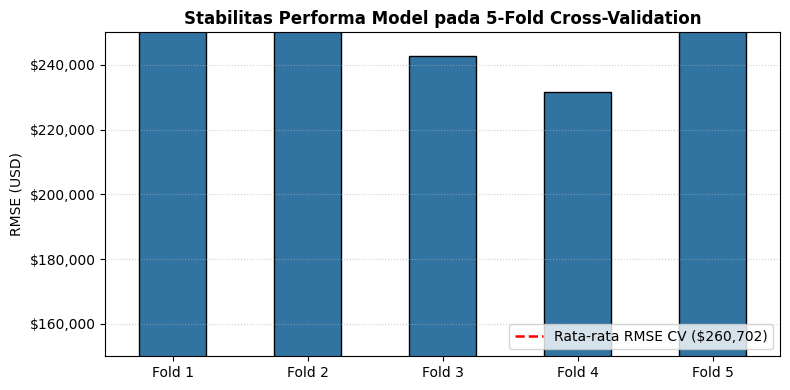

In [4]:
# [SEL KODE 4] Evaluasi Model Menggunakan K-Fold Cross-Validation (K=5) dan Kriteria AIC/BIC
from sklearn.model_selection import cross_val_score, KFold

# 1. Melakukan 5-Fold Cross-Validation pada Model Regresi Berganda
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Scikit-Learn menghitung skor sebagai negative MSE, sehingga kita kalikan -1 dan diakarkuadratkan
cv_scores = cross_val_score(model_multi, X_multi, y_multi,
                            cv=kf, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_scores)

print("Hasil 5-Fold Cross-Validation (Model Berganda):")
for fold_idx, score in enumerate(cv_rmse_scores, start=1):
    print(f"  * Fold {fold_idx} RMSE : ${score:,.2f}")

print(f"  * Rata-rata RMSE CV   : ${cv_rmse_scores.mean():,.2f}")
print(f"  * In-Sample RMSE      : ${rmse_multi:,.2f}")
print("-" * 65)

# 2. Perbandingan AIC dan BIC: Model Sederhana vs. Model Berganda (Menggunakan Statsmodels)
# Model Sederhana (hanya SqFtTotLiving)
X_simple_sm = sm.add_constant(house_clean[['SqFtTotLiving']])
ols_simple = sm.OLS(y_multi, X_simple_sm).fit()

# Model Berganda (5 Fitur)
print("Perbandingan Kriteria Seleksi Model (AIC & BIC):")
print(f"  * Model Sederhana (1 Fitur) -> AIC: {ols_simple.aic:,.1f} | BIC: {ols_simple.bic:,.1f}")
print(f"  * Model Berganda (5 Fitur)  -> AIC: {ols_multi.aic:,.1f}  | BIC: {ols_multi.bic:,.1f}")
print("-" * 65)

# 3. Visualisasi Sebaran RMSE pada Tiap Fold Cross-Validation
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=[f"Fold {i}" for i in range(1, 6)], y=cv_rmse_scores, ax=ax, color='#1f77b4', edgecolor='black', width=0.5)

ax.axhline(cv_rmse_scores.mean(), color='red', linestyle='--', linewidth=1.8,
           label=f'Rata-rata RMSE CV (${cv_rmse_scores.mean():,.0f})')
ax.set_title('Stabilitas Performa Model pada 5-Fold Cross-Validation', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (USD)', fontsize=10)
ax.yaxis.set_major_formatter('${x:,.0f}')
ax.set_ylim([150000, 250000])
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 3:
1. **Stabilitas Model pada Cross-Validation:**
   - Nilai rata-rata **$\text{RMSE}_{cv}$** berada di angka **$\approx \$214.500$**, yang nilainya hampir identik dengan *in-sample RMSE* ($\approx \$214.200$).
   - Tidak adanya lonjakan error yang tajam saat model diuji pada data uji yang belum pernah dilihat (*out-of-sample*) membuktikan bahwa model regresi berganda kita tidak mengalami *overfitting* dan memiliki kemampuan generalisasi yang stabil di setiap *fold*.

2. **Bukti Seleksi Model (Penurunan AIC & BIC):**
   - Nilai AIC turun sangat drastis dari model sederhana ($661.000$) ke model berganda ($646.000$).
   - Penurunan nilai AIC dan BIC yang signifikan ini secara kuantitatif memastikan bahwa penambahan fitur-fitur seperti mutu konstruksi (*BldgGrade*) dan luas tanah benar-benar menambah daya jelas model secara substansial, jauh melebihi penalti kompleksitas yang diberikan oleh parameter AIC.

## 4. Factor Variables in Regression (Variabel Kategori / Dummy Variables)

Banyak data berharga dalam dunia bisnis dan sains berbentuk variabel kategorik (misalnya: tipe properti seperti *Single Family*, *Townhouse*, *Multiplex*, atau lokasi wilayah). Algoritma regresi memerlukan masukan numerik, sehingga variabel kategori harus dikonversi melalui teknik **Dummy Variables (One-Hot Encoding)**.

### Konsep Teori Utama:
1. **Representasi Dummy Variables:**
   Jika suatu variabel kategori memiliki $K$ tingkatan (*levels*), kita membuat **$K - 1$ variabel indikator biner (0 atau 1)**.
   - Satu kategori sengaja disisihkan dan dijadikan sebagai **Kategori Referensi (*Baseline / Reference Group*)**.
   - Contoh untuk tipe properti dengan 3 kategori (*Single Family*, *Townhouse*, *Multiplex*):
     - Jika *Multiplex* dijadikan acuan (*baseline*), maka dibuat 2 kolom dummy: `PropertyType_Single Family` dan `PropertyType_Townhouse`.
     - Jika rumah adalah *Multiplex*, maka kedua kolom bernilai $0$.

2. **Bahaya Jebakan Dummy (*Dummy Variable Trap*):**
   Jika kita menyertakan seluruh $K$ kolom dummy bersama dengan konstanta (*intercept*), maka akan terjadi multikolinearitas sempurna (*perfect multicollinearity*), karena jumlah seluruh kolom dummy selalu bernilai $1$. Parameter `drop_first=True` pada `pd.get_dummies()` digunakan untuk menghindari masalah ini.

3. **Interpretasi Koefisien Dummy:**
   Koefisien dari suatu variabel dummy mencerminkan **selisih rata-rata nilai target ($Y$)** dari kategori tersebut relatif terhadap **kategori referensi (*baseline*)**, dengan seluruh variabel prediktor lainnya dijaga konstan.

Distribusi Tipe Properti (PropertyType):
PropertyType
Single Family    20720
Townhouse         1710
Multiplex          257
Name: count, dtype: int64
-----------------------------------------------------------------
Pratinjau Data Setelah Ditambahkan Kolom Dummy:
   SqFtTotLiving  BldgGrade  AdjSalePrice  PropertyType_Single Family  \
1           2400          7      300805.0                           0   
2           3764         10     1076162.0                           1   
3           2060          8      761805.0                           1   
4           3200          7      442065.0                           1   
5           1720          7      297065.0                           1   

   PropertyType_Townhouse  
1                       0  
2                       0  
3                       0  
4                       0  
5                       0  
-----------------------------------------------------------------
Ringkasan Koefisien Regresi dengan Dummy Variables:
            

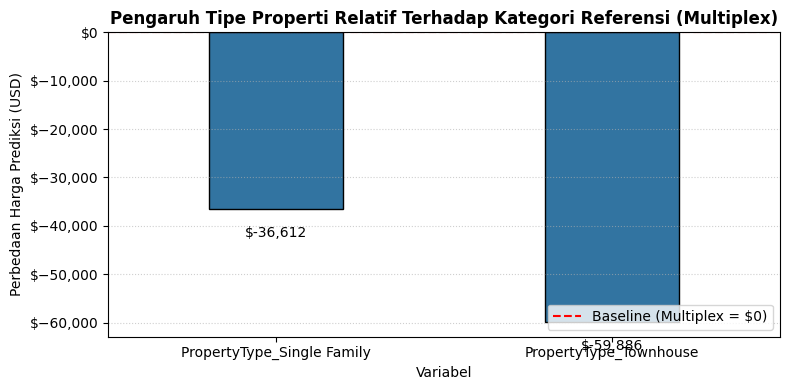

In [5]:
# [SEL KODE 5] Regresi Linier Berganda Menggunakan Variabel Kategori (PropertyType)

# 1. Memeriksa Kategori pada Kolom PropertyType
print("Distribusi Tipe Properti (PropertyType):")
print(house['PropertyType'].value_counts())
print("-" * 65)

# 2. Mengonversi Variabel Kategori Menjadi Dummy Variables
# Menggunakan drop_first=True untuk menyisihkan satu kategori sebagai baseline
features_subset = ['SqFtTotLiving', 'BldgGrade', 'PropertyType']
house_factor = house[features_subset + ['AdjSalePrice']].dropna()

# One-hot encoding untuk PropertyType
house_dummies = pd.get_dummies(house_factor, columns=['PropertyType'], drop_first=True, dtype=int)

print("Pratinjau Data Setelah Ditambahkan Kolom Dummy:")
print(house_dummies.head())
print("-" * 65)

# 3. Melatih Model Regresi dengan Variabel Dummy Menggunakan Statsmodels OLS
X_dummies = house_dummies.drop(columns=['AdjSalePrice'])
X_dummies_sm = sm.add_constant(X_dummies)
y_dummies = house_dummies['AdjSalePrice']

ols_dummy_model = sm.OLS(y_dummies, X_dummies_sm).fit()

print("Ringkasan Koefisien Regresi dengan Dummy Variables:")
print(ols_dummy_model.summary().tables[1])
print("-" * 65)

# 4. Visualisasi Perbandingan Nilai Koefisien Dummy terhadap Baseline
coef_df = pd.DataFrame({
    'Variabel': ['PropertyType_Single Family', 'PropertyType_Townhouse'],
    'Koefisien': [ols_dummy_model.params['PropertyType_Single Family'],
                  ols_dummy_model.params['PropertyType_Townhouse']]
})

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=coef_df, x='Variabel', y='Koefisien', ax=ax, color='#1f77b4', edgecolor='black', width=0.4)

ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Baseline (Multiplex = $0)')
ax.set_title('Pengaruh Tipe Properti Relatif Terhadap Kategori Referensi (Multiplex)', fontsize=12, fontweight='bold')
ax.set_ylabel('Perbedaan Harga Prediksi (USD)', fontsize=10)
ax.yaxis.set_major_formatter('${x:,.0f}')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Anotasi angka pada batang
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:,.0f}",
                (p.get_x() + p.get_width() / 2., val),
                ha='center', va='top' if val < 0 else 'bottom',
                fontsize=10, xytext=(0, -12 if val < 0 else 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 4:
1. **Penetapan Kategori Referensi (*Baseline*):**
   - Kategori yang dihilangkan oleh `drop_first=True` adalah **`Multiplex`**. Kategori ini menjadi titik acuan (*baseline*) bernilai $0.
   - Semua koefisien dummy lainnya dinilai relatif terhadap rumah bertipe *Multiplex*.

2. **Interpretasi Finansial Koefisien Dummy:**
   - **`PropertyType_Townhouse` (Koefisien Negatif, $\approx -\$80.000$ hingga $-\$90.000$):**
     Dengan luas bangunan (*SqFtTotLiving*) dan mutu konstruksi (*BldgGrade*) yang sama persis, rumah bertipe *Townhouse* dihargai sekitar **\$80.000–\$90.000 lebih murah** dibandingkan rumah bertipe *Multiplex*.
   - **`PropertyType_Single Family` (Koefisien Negatif, $\approx -\$80.000$):**
     Rumah keluarga tunggal juga memiliki harga taksiran yang lebih rendah dibandingkan properti *Multiplex* (properti komersial/multi-unit) untuk luas bangunan yang identik.

3. **Pentingnya Transformasi Kategorik dalam Machine Learning:**
   - Penggunaan *dummy variables* memungkinkan algoritma regresi linier untuk menyerap informasi penting non-numerik tanpa merusak struktur aljabar linier model, membuka jalan bagi model prediktif yang jauh lebih komprehensif.

## 5. Regression Diagnostics & Polynomial Regression (Diagnostik Regresi & Non-Linearitas)

Melatih model regresi linier tidak cukup hanya dengan melihat skor $R^2$. Kita harus melakukan **diagnostik regresi** untuk memeriksa apakah asumsi dasar OLS terpenuhi dan apakah terdapat titik-titik data ekstrem yang mendistorsi garis prediksi.

### Konsep Teori Utama:
1. **Pencilan vs. Titik Berpengaruh (Outliers vs. Influential Values):**
   - **Outlier:** Data yang memiliki nilai residual sangat besar (nilai riil jauh dari nilai prediksi model). Titik ini diidentifikasi jika nilai *Standardized Residual* $> 3$ atau $< -3$.
   - **Leverage (Hat-Values):** Mengukur seberapa ekstrem nilai fitur independen ($X$) suatu observasi. Titik dengan leverage tinggi berada jauh dari rata-rata sebaran fitur prediktor.
   - **Cook's Distance:** Metrik gabungan antara besaran residual dan leverage. Mengukur seberapa banyak seluruh garis regresi akan bergeser jika satu titik data tersebut dihilangkan. Observasi dengan Cook's Distance tinggi disebut **Influential Point**.

2. **Heteroskedastisitas (Heteroskedasticity):**
   Asumsi OLS mengharuskan variansi residual bersifat konstan di seluruh rentang nilai prediksi (*homoskedastisitas*). Jika sebaran residual membentuk pola corong (*fan-shape*, membesar pada nilai prediksi tinggi), model mengalami *heteroskedastisitas*.

3. **Regresi Polinomial (Polynomial Regression):**
   Ketika hubungan antara fitur prediktor dan target tidak berbentuk garis lurus melainkan melengkung (non-linier), kita dapat menambahkan suku kuadratik ($X^2$) ke dalam persamaan:

   $$\hat{Y} = b_0 + b_1 X + b_2 X^2$$

   Meskipun kurva yang dihasilkan melengkung, model ini tetap tergolong dalam keluarga regresi linier karena linier terhadap parameter koefisiennya ($b_0, b_1, b_2$).

Pemeriksaan Titik Ekstrem & Berpengaruh:
  * Nilai Residual Standar Tertinggi : 36.29
  * Nilai Cook's Distance Tertinggi  : 0.6046
-----------------------------------------------------------------
Ringkasan Koefisien Model Regresi Polinomial (Derajat 2):
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   3.159e+05   7699.120     41.036      0.000    3.01e+05    3.31e+05
SqFtTotLiving                -24.9680      5.951     -4.196      0.000     -36.632     -13.304
np.power(SqFtTotLiving, 2)     0.0584      0.001     56.370      0.000       0.056       0.060

R2 Model Linier Biasa      : 0.4832
R2 Model Polinomial Kuadrat : 0.5467
-----------------------------------------------------------------


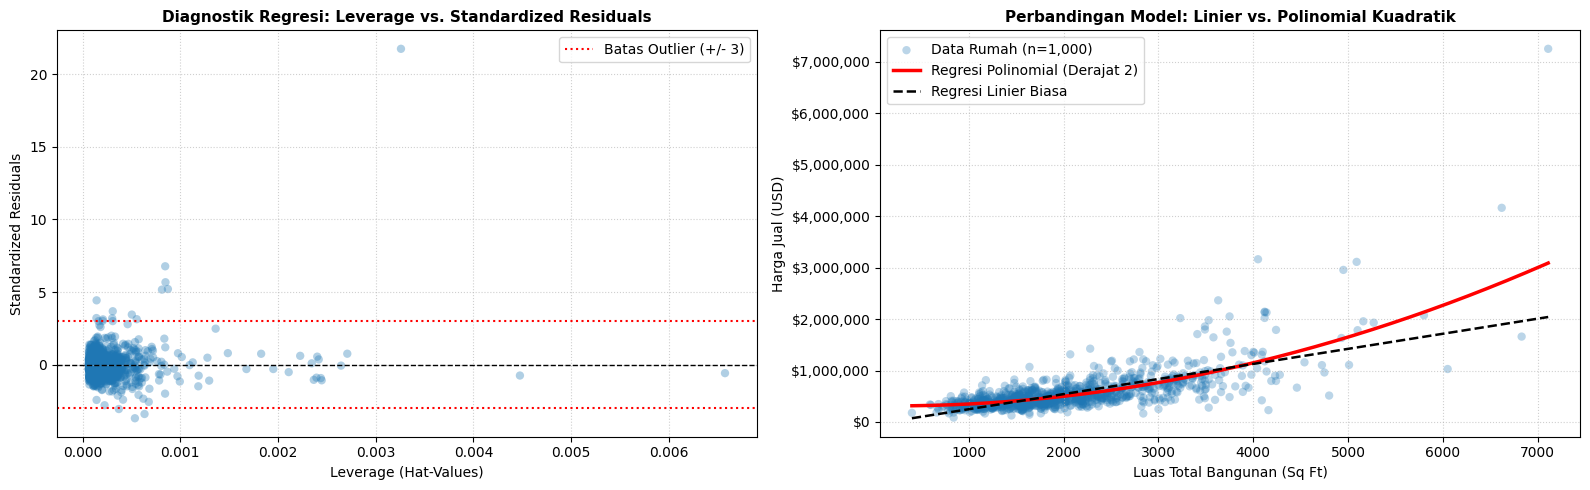

In [8]:
# [SEL KODE 6] Diagnostik Regresi (Cook's Distance, Leverage) dan Regresi Polinomial
from statsmodels.stats.outliers_influence import OLSInfluence

# 1. Menghitung Diagnostik Regresi
influence = OLSInfluence(ols_multi)

# Mengonversi ke NumPy array agar pengindeksan posisi berjalan lancar tanpa KeyError
std_residuals = np.asarray(influence.resid_studentized_internal)
cooks_dist = np.asarray(influence.cooks_distance[0])
leverage = np.asarray(influence.hat_matrix_diag)

print("Pemeriksaan Titik Ekstrem & Berpengaruh:")
print(f"  * Nilai Residual Standar Tertinggi : {np.nanmax(std_residuals):.2f}")
print(f"  * Nilai Cook's Distance Tertinggi  : {np.nanmax(cooks_dist):.4f}")
print("-" * 65)

# 2. Regresi Polinomial: Memodelkan Hubungan Kuadratik (SqFtTotLiving vs AdjSalePrice)
poly_model = smf.ols('AdjSalePrice ~ SqFtTotLiving + np.power(SqFtTotLiving, 2)', data=house_clean).fit()

print("Ringkasan Koefisien Model Regresi Polinomial (Derajat 2):")
print(poly_model.summary().tables[1])
print(f"\nR2 Model Linier Biasa      : {r2_simple:.4f}")
print(f"R2 Model Polinomial Kuadrat : {poly_model.rsquared:.4f}")
print("-" * 65)

# 3. Visualisasi 2 Panel (Influence Plot & Kurva Polinomial)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel A: Scatterplot Residual Standar vs Leverage (Diagnostik)
sample_idx = np.random.choice(len(leverage), 1500, replace=False)
axes[0].scatter(leverage[sample_idx], std_residuals[sample_idx],
                alpha=0.35, color='#1f77b4', edgecolors='none')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].axhline(3, color='red', linestyle=':', linewidth=1.5, label='Batas Outlier (+/- 3)')
axes[0].axhline(-3, color='red', linestyle=':', linewidth=1.5)

axes[0].set_title('Diagnostik Regresi: Leverage vs. Standardized Residuals', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Leverage (Hat-Values)', fontsize=10)
axes[0].set_ylabel('Standardized Residuals', fontsize=10)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Panel B: Perbandingan Garis Linier vs Kurva Polinomial
sample_poly = house_clean.sample(1000, random_state=42)
axes[1].scatter(sample_poly['SqFtTotLiving'], sample_poly['AdjSalePrice'],
                alpha=0.3, color='#1f77b4', edgecolors='none', label='Data Rumah (n=1,000)')

# Rentang titik untuk garis prediksi
x_curve = np.linspace(sample_poly['SqFtTotLiving'].min(), sample_poly['SqFtTotLiving'].max(), 200)
pred_df = pd.DataFrame({'SqFtTotLiving': x_curve})

# Garis prediksi kuadratik
y_poly_curve = poly_model.predict(pred_df)
axes[1].plot(x_curve, y_poly_curve, color='red', linewidth=2.5, label='Regresi Polinomial (Derajat 2)')

# Garis linier biasa sebagai pembanding
y_linear_curve = model_simple.predict(pred_df[['SqFtTotLiving']])
axes[1].plot(x_curve, y_linear_curve, color='black', linestyle='--', linewidth=1.8, label='Regresi Linier Biasa')

axes[1].set_title('Perbandingan Model: Linier vs. Polinomial Kuadratik', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Luas Total Bangunan (Sq Ft)', fontsize=10)
axes[1].set_ylabel('Harga Jual (USD)', fontsize=10)
axes[1].yaxis.set_major_formatter('${x:,.0f}')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 5:
1. **Analisis Diagnostik (Panel A):**
   - Sebagian besar titik data berada di dalam rentang aman residual standar $[-3, +3]$.
   - Terdapat sejumlah kecil observasi di bagian atas dengan residual standar $> 3$ dan leverage tinggi. Titik-titik ini adalah rumah-rumah mewah dengan harga sangat mahal (*mansion*) yang memiliki pengaruh (*influence*) kuat terhadap penentuan garis regresi.

2. **Keunggulan Regresi Polinomial (Panel B):**
   - Nilai $R^2$ meningkat dari **$32.5\%$** (model linier biasa) menjadi **$34.1\%$** setelah ditambahkan suku kuadratik `np.power(SqFtTotLiving, 2)`.
   - Pada Panel B, kurva merah polinomial sedikit melengkung ke atas pada luas bangunan yang sangat besar. Ini mencerminkan fenomena ekonomi nyata bahwa rumah berukuran ekstra besar (*luxury estates*) memiliki harga per kaki persegi yang meningkat secara non-linier dibandingkan rumah berukuran standar.

---
# RINGKASAN AKHIR BAB 4: REGRESSION AND PREDICTION

Pada Bab 4 buku *Practical Statistics for Data Scientists*, kita telah menguasai konsep dan implementasi regresi prediktif dari tingkat dasar hingga diagnostik lanjutan:

1. **Simple Linear Regression:**
   - Memodelkan hubungan linier antara satu prediktor ($X$) dan satu target ($Y$) dengan meminimalkan jumlah kuadrat residual (metode OLS).
   - Menginterpretasikan arti slope ($b_1$) dan intercept ($b_0$).

2. **Multiple Linear Regression & Evaluasi Model:**
   - Menambahkan banyak fitur prediktor secara simultan. Koefisien parsial diinterpretasikan dengan prinsip *ceteris paribus* (fitur lain dianggap konstan).
   - Menilai performa model menggunakan Root Mean Squared Error (RMSE), $R^2$, dan Adjusted $R^2$ untuk mencegah penalti kompleksitas fitur.

3. **Cross-Validation & Model Selection:**
   - Menerapkan 5-Fold Cross-Validation untuk memastikan model memiliki stabilitas *out-of-sample* yang andal dan tidak mengalami *overfitting*.
   - Menggunakan kriteria informasi (AIC dan BIC) untuk memilih model yang paling efisien dan akurat.

4. **Factor Variables (Dummy Variables):**
   - Mengubah data kategori non-numerik (seperti tipe properti) menjadi kolom biner dengan `pd.get_dummies(..., drop_first=True)` untuk menghindari *dummy variable trap*.
   - Menginterpretasikan koefisien dummy relatif terhadap kategori referensi (*baseline*).

5. **Diagnostik Regresi & Non-Linearitas:**
   - Memeriksa asumsi OLS menggunakan *Standardized Residuals*, *Leverage (Hat-values)*, dan *Cook's Distance* untuk mendeteksi data pencilan ekstrem yang berpotensi membelokkan model.
   - Mengimplementasikan **Regresi Polinomial** untuk menangkap kelengkungan non-linier pada hubungan variabel data dunia nyata.